In [242]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import brier_score_loss
from itertools import combinations
import xgboost as xgb
from sklearn.metrics import brier_score_loss

In [243]:
men_detailed = pd.read_csv('/kaggle/input/competitions/march-machine-learning-mania-2026/MRegularSeasonDetailedResults.csv')
print(f"Shape: {men_detailed.shape}")
men_detailed.head()

Shape: (124529, 34)


,Season,DayNum,WTeamID,WScore,LTeamID,LScore,WLoc,NumOT,WFGM,WFGA,...,LFGA3,LFTM,LFTA,LOR,LDR,LAst,LTO,LStl,LBlk,LPF
0,2003,10,1104,68,1328,62,N,0,27,58,...,10,16,22,10,22,8,18,9,2,20
1,2003,10,1272,70,1393,63,N,0,26,62,...,24,9,20,20,25,7,12,8,6,16
2,2003,11,1266,73,1437,61,N,0,24,58,...,26,14,23,31,22,9,12,2,5,23
3,2003,11,1296,56,1457,50,N,0,18,38,...,22,8,15,17,20,9,19,4,3,23
4,2003,11,1400,77,1208,71,N,0,30,61,...,16,17,27,21,15,12,10,7,1,14


In [244]:
# Print all column names
print(men_detailed.columns.tolist())

['Season', 'DayNum', 'WTeamID', 'WScore', 'LTeamID', 'LScore', 'WLoc', 'NumOT', 'WFGM', 'WFGA', 'WFGM3', 'WFGA3', 'WFTM', 'WFTA', 'WOR', 'WDR', 'WAst', 'WTO', 'WStl', 'WBlk', 'WPF', 'LFGM', 'LFGA', 'LFGM3', 'LFGA3', 'LFTM', 'LFTA', 'LOR', 'LDR', 'LAst', 'LTO', 'LStl', 'LBlk', 'LPF']


In [374]:
# Look at the first row (index 0)
mfirst_game = men_detailed.iloc[0]

# Winner's FG% = FGM / FGA
w_fg_pct = mfirst_game['WFGM'] / mfirst_game['WFGA'] if mfirst_game['WFGA'] > 0 else 0
print(f"Winner's FG%: {w_fg_pct:.3f}")

# Loser's FG%
l_fg_pct = mfirst_game['LFGM'] / mfirst_game['LFGA'] if mfirst_game['LFGA'] > 0 else 0
print(f"Loser's FG%: {l_fg_pct:.3f}")

Winner's FG%: 0.466
Loser's FG%: 0.415


In [375]:
# Add new columns for FG% for winner and loser
men_detailed['WFGpct'] = men_detailed['WFGM'] / men_detailed['WFGA']
men_detailed['LFGpct'] = men_detailed['LFGM'] / men_detailed['LFGA']

# Check the first 5 values
men_detailed[['WFGpct', 'LFGpct']].head()

,WFGpct,LFGpct
0,0.465517,0.415094
1,0.419355,0.358209
2,0.413793,0.301370
3,0.473684,0.367347
4,0.491803,0.387097


In [376]:
# Check for null values in each column
men_detailed.isnull().sum()

Season      0
DayNum      0
WTeamID     0
WScore      0
LTeamID     0
LScore      0
WLoc        0
NumOT       0
WFGM        0
WFGA        0
WFGM3       0
WFGA3       0
WFTM        0
WFTA        0
WOR         0
WDR         0
WAst        0
WTO         0
WStl        0
WBlk        0
WPF         0
LFGM        0
LFGA        0
LFGM3       0
LFGA3       0
LFTM        0
LFTA        0
LOR         0
LDR         0
LAst        0
LTO         0
LStl        0
LBlk        0
LPF         0
WFGpct      0
LFGpct      0
W3Ppct      0
WFTPct      7
WeFGpct     0
L3Ppct      0
LFTPct     41
LeFGpct     0
WPoss       0
LPoss       0
WOE         0
LOE         0
dtype: int64

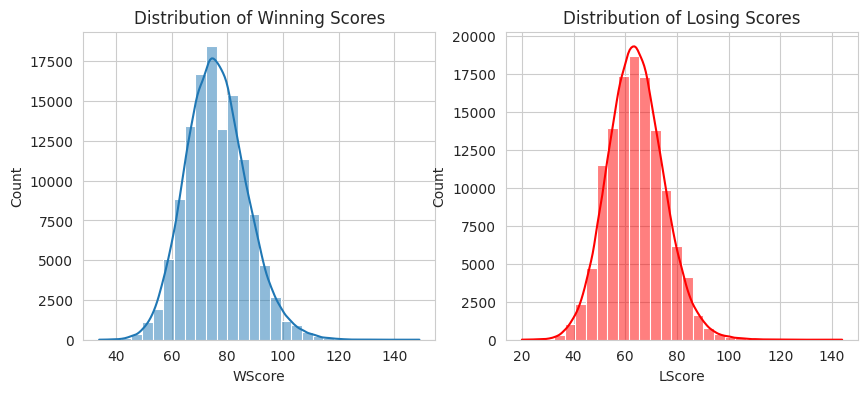

In [248]:
sns.set_style('whitegrid')

# Plot histogram of winning scores
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
sns.histplot(men_detailed['WScore'], bins=30, kde=True)
plt.title('Distribution of Winning Scores')

plt.subplot(1,2,2)
sns.histplot(men_detailed['LScore'], bins=30, kde=True, color='red')
plt.title('Distribution of Losing Scores')
plt.show()

In [249]:
game = men_detailed.iloc[0]

# Winner's possessions
w_poss = game['WFGA'] + 0.44 * game['WFTA'] + game['WTO'] - game['WOR']

# Loser's possessions
l_poss = game['LFGA'] + 0.44 * game['LFTA'] + game['LTO'] - game['LOR']

print(f"Winner possessions: {w_poss:.1f}")
print(f"Loser possessions: {l_poss:.1f}")
print(f"Game pace (avg possessions): {(w_poss + l_poss)/2:.1f}")

Winner possessions: 74.9
Loser possessions: 70.7
Game pace (avg possessions): 72.8


In [250]:
w_oe = game['WScore'] / w_poss * 100  # points per 100 possessions
l_oe = game['LScore'] / l_poss * 100

print(f"Winner offensive efficiency: {w_oe:.1f}")
print(f"Loser offensive efficiency: {l_oe:.1f}")

Winner offensive efficiency: 90.8
Loser offensive efficiency: 87.7


In [252]:
# Calculate possessions for winner and loser for ALL games
men_detailed['WPoss'] = men_detailed['WFGA'] + 0.44 * men_detailed['WFTA'] + men_detailed['WTO'] - men_detailed['WOR']
men_detailed['LPoss'] = men_detailed['LFGA'] + 0.44 * men_detailed['LFTA'] + men_detailed['LTO'] - men_detailed['LOR']

# Calculate offensive efficiency (points per 100 possessions)
men_detailed['WOE'] = men_detailed['WScore'] / men_detailed['WPoss'] * 100
men_detailed['LOE'] = men_detailed['LScore'] / men_detailed['LPoss'] * 100

# Check the new columns
men_detailed[['WPoss', 'LPoss', 'WOE', 'LOE']].head()

,WPoss,LPoss,WOE,LOE
0,74.92,70.68,90.763481,87.719298
1,68.36,67.80,102.399064,92.920354
2,63.76,64.12,114.491844,95.134124
3,57.64,57.60,97.154754,86.805556
4,63.72,62.88,120.841180,112.913486


In [253]:
# Winner shooting
men_detailed['WFGpct'] = men_detailed['WFGM'] / men_detailed['WFGA'].replace(0, np.nan)
men_detailed['W3Ppct'] = men_detailed['WFGM3'] / men_detailed['WFGA3'].replace(0, np.nan)
men_detailed['WFTPct'] = men_detailed['WFTM'] / men_detailed['WFTA'].replace(0, np.nan)
men_detailed['WeFGpct'] = (men_detailed['WFGM'] + 0.5*men_detailed['WFGM3']) / men_detailed['WFGA'].replace(0, np.nan)

# Loser shooting
men_detailed['LFGpct'] = men_detailed['LFGM'] / men_detailed['LFGA'].replace(0, np.nan)
men_detailed['L3Ppct'] = men_detailed['LFGM3'] / men_detailed['LFGA3'].replace(0, np.nan)
men_detailed['LFTPct'] = men_detailed['LFTM'] / men_detailed['LFTA'].replace(0, np.nan)
men_detailed['LeFGpct'] = (men_detailed['LFGM'] + 0.5*men_detailed['LFGM3']) / men_detailed['LFGA'].replace(0, np.nan)
men_detailed.head()

,Season,DayNum,WTeamID,WScore,LTeamID,LScore,WLoc,NumOT,WFGM,WFGA,...,W3Ppct,WFTPct,WeFGpct,L3Ppct,LFTPct,LeFGpct,WPoss,LPoss,WOE,LOE
0,2003,10,1104,68,1328,62,N,0,27,58,...,0.214286,0.611111,0.491379,0.200000,0.727273,0.433962,74.92,70.68,90.763481,87.719298
1,2003,10,1272,70,1393,63,N,0,26,62,...,0.400000,0.526316,0.483871,0.250000,0.450000,0.402985,68.36,67.80,102.399064,92.920354
2,2003,11,1266,73,1437,61,N,0,24,58,...,0.444444,0.586207,0.482759,0.115385,0.608696,0.321918,63.76,64.12,114.491844,95.134124
3,2003,11,1296,56,1457,50,N,0,18,38,...,0.333333,0.548387,0.513158,0.272727,0.533333,0.428571,57.64,57.60,97.154754,86.805556
4,2003,11,1400,77,1208,71,N,0,30,61,...,0.428571,0.846154,0.540984,0.375000,0.629630,0.435484,63.72,62.88,120.841180,112.913486


In [254]:
# Winners
winners = men_detailed[[
    'Season', 'DayNum', 'WTeamID', 'WScore', 'LTeamID', 'LScore',
    'WPoss', 'LPoss', 'WOE', 'LOE', 'WLoc',
    'WFGpct', 'W3Ppct', 'WFTPct', 'WeFGpct',
    'LFGpct', 'L3Ppct', 'LFTPct', 'LeFGpct'
]].copy()
winners.columns = [
    'Season', 'DayNum', 'TeamID', 'TeamScore', 'OppID', 'OppScore',
    'TeamPoss', 'OppPoss', 'TeamOE', 'OppOE', 'Loc',
    'TeamFGpct', 'Team3Ppct', 'TeamFTpct', 'TeameFGpct',
    'OppFGpct', 'Opp3Ppct', 'OppFTpct', 'OppeFGpct'
]
winners['Loc'] = winners['Loc'].map({'H':1, 'A':-1, 'N':0})

# Losers
losers = men_detailed[[
    'Season', 'DayNum', 'LTeamID', 'LScore', 'WTeamID', 'WScore',
    'LPoss', 'WPoss', 'LOE', 'WOE',
    'LFGpct', 'L3Ppct', 'LFTPct', 'LeFGpct',
    'WFGpct', 'W3Ppct', 'WFTPct', 'WeFGpct'
]].copy()
losers.columns = [
    'Season', 'DayNum', 'TeamID', 'TeamScore', 'OppID', 'OppScore',
    'TeamPoss', 'OppPoss', 'TeamOE', 'OppOE',
    'TeamFGpct', 'Team3Ppct', 'TeamFTpct', 'TeameFGpct',
    'OppFGpct', 'Opp3Ppct', 'OppFTpct', 'OppeFGpct'
]
losers['Loc'] = men_detailed['WLoc'].map({'H':-1, 'A':1, 'N':0})

# Combine
men_team_games = pd.concat([winners, losers], ignore_index=True)
men_team_games = men_team_games.sort_values(['Season', 'DayNum', 'TeamID'])
men_team_games.head(10)

,Season,DayNum,TeamID,TeamScore,OppID,OppScore,TeamPoss,OppPoss,TeamOE,OppOE,Loc,TeamFGpct,Team3Ppct,TeamFTpct,TeameFGpct,OppFGpct,Opp3Ppct,OppFTpct,OppeFGpct
0,2003,10,1104,68,1328,62,74.92,70.68,90.763481,87.719298,0,0.465517,0.214286,0.611111,0.491379,0.415094,0.200000,0.727273,0.433962
1,2003,10,1272,70,1393,63,68.36,67.80,102.399064,92.920354,0,0.419355,0.400000,0.526316,0.483871,0.358209,0.250000,0.450000,0.402985
124529,2003,10,1328,62,1104,68,70.68,74.92,87.719298,90.763481,0,0.415094,0.200000,0.727273,0.433962,0.465517,0.214286,0.611111,0.491379
124530,2003,10,1393,63,1272,70,67.80,68.36,92.920354,102.399064,0,0.358209,0.250000,0.450000,0.402985,0.419355,0.400000,0.526316,0.483871
124534,2003,11,1186,55,1458,81,66.48,65.88,82.731649,122.950820,-1,0.434783,0.272727,0.705882,0.467391,0.456140,0.500000,0.851852,0.508772
124533,2003,11,1208,71,1400,77,62.88,63.72,112.913486,120.841180,0,0.387097,0.375000,0.629630,0.435484,0.491803,0.428571,0.846154,0.540984
2,2003,11,1266,73,1437,61,63.76,64.12,114.491844,95.134124,0,0.413793,0.444444,0.586207,0.482759,0.301370,0.115385,0.608696,0.321918
3,2003,11,1296,56,1457,50,57.64,57.60,97.154754,86.805556,0,0.473684,0.333333,0.548387,0.513158,0.367347,0.272727,0.533333,0.428571
4,2003,11,1400,77,1208,71,63.72,62.88,120.841180,112.913486,0,0.491803,0.428571,0.846154,0.540984,0.387097,0.375000,0.629630,0.435484
124531,2003,11,1437,61,1266,73,64.12,63.76,95.134124,114.491844,0,0.301370,0.115385,0.608696,0.321918,0.413793,0.444444,0.586207,0.482759


In [354]:
# Group by Season and TeamID, calculate mean stats
team_season_stats = men_team_games.groupby(['Season', 'TeamID']).agg({
    'TeamOE': 'mean', 'OppOE': 'mean',
    'TeamPoss': 'mean', 'TeamScore': 'mean', 'OppScore': 'mean',
    'TeamFGpct': 'mean', 'Team3Ppct': 'mean', 'TeamFTpct': 'mean', 'TeameFGpct': 'mean',
    'OppFGpct': 'mean', 'Opp3Ppct': 'mean', 'OppFTpct': 'mean', 'OppeFGpct': 'mean'         
}).reset_index()

# Rename columns to include all stats
team_season_stats.columns = [
    'Season', 'TeamID', 
    'OffEff', 'DefEff', 'Pace', 'PointsScored', 'PointsAllowed',
    'FGpct', '3Ppct', 'FTpct', 'eFGpct',
    'OppFGpct', 'Opp3Ppct', 'OppFTpct', 'Opp_eFGpct'
]

# Verify all columns are there
print(team_season_stats.shape)
print(team_season_stats.columns.tolist())

(8346, 15)
['Season', 'TeamID', 'OffEff', 'DefEff', 'Pace', 'PointsScored', 'PointsAllowed', 'FGpct', '3Ppct', 'FTpct', 'eFGpct', 'OppFGpct', 'Opp3Ppct', 'OppFTpct', 'Opp_eFGpct']


In [355]:
# create a lookup of team-season stats
team_stats_lookup = team_season_stats.set_index(['Season', 'TeamID'])

# Now for each game in team_games, get opponent's OffEff and DefEff
team_games['OppOffEff'] = team_games.apply(
    lambda row: team_stats_lookup.loc[(row['Season'], row['OppID']), 'OffEff'], axis=1
)
team_games['OppDefEff'] = team_games.apply(
    lambda row: team_stats_lookup.loc[(row['Season'], row['OppID']), 'DefEff'], axis=1
)

# Then group by team-season to get average opponent stats
sos_stats = team_games.groupby(['Season', 'TeamID']).agg({
    'OppOffEff': 'mean',   # average offensive efficiency of opponents (how good they were on offense)
    'OppDefEff': 'mean'    # average defensive efficiency of opponents (how good they were on defense)
}).reset_index()

# Merge with existing team_season_stats
team_season_stats = team_season_stats.merge(sos_stats, on=['Season', 'TeamID'])

# Now we have SOS info: a team faced opponents that on average had OffEff X and DefEff Y.
team_season_stats.head()

,Season,TeamID,OffEff,DefEff,Pace,PointsScored,PointsAllowed,FGpct,3Ppct,FTpct,eFGpct,OppFGpct,Opp3Ppct,OppFTpct,Opp_eFGpct,OppOffEff,OppDefEff
0,2003,1102,104.902619,105.142005,54.562857,57.250000,57.000000,0.486149,0.367637,0.642402,0.584407,0.458038,0.379754,0.719462,0.514142,104.516225,103.512261
1,2003,1103,111.985073,111.829472,70.078519,78.777778,78.148148,0.487294,0.331990,0.735271,0.536564,0.490044,0.369966,0.735661,0.549098,103.724912,105.253598
2,2003,1104,104.527648,98.975644,66.101429,69.285714,65.000000,0.419676,0.325442,0.705168,0.475785,0.422397,0.330969,0.712597,0.480099,104.492967,99.247378
3,2003,1105,93.942187,102.129410,76.381538,71.769231,76.653846,0.396204,0.359630,0.709598,0.457983,0.456482,0.355629,0.669716,0.509308,96.030209,101.820369
4,2003,1106,94.469094,95.562829,67.280000,63.607143,63.750000,0.425530,0.350196,0.623158,0.481697,0.408549,0.298856,0.711733,0.452774,98.558033,101.762764


In [357]:
# Drop the duplicate '_y' columns and rename '_x' to the original names
men_stats = team_season_stats[[col for col in team_season_stats.columns if not col.endswith('_y')]]
men_stats.columns = [col.replace('_x', '') if col.endswith('_x') else col for col in men_stats.columns]

# Now men_stats should have clean columns: Season, TeamID, OffEff, DefEff, Pace, PointsScored, PointsAllowed, OppOffEff, OppDefEff
men_stats.head()

,Season,TeamID,OffEff,DefEff,Pace,PointsScored,PointsAllowed,FGpct,3Ppct,FTpct,eFGpct,OppFGpct,Opp3Ppct,OppFTpct,Opp_eFGpct,OppOffEff,OppDefEff
0,2003,1102,104.902619,105.142005,54.562857,57.250000,57.000000,0.486149,0.367637,0.642402,0.584407,0.458038,0.379754,0.719462,0.514142,104.516225,103.512261
1,2003,1103,111.985073,111.829472,70.078519,78.777778,78.148148,0.487294,0.331990,0.735271,0.536564,0.490044,0.369966,0.735661,0.549098,103.724912,105.253598
2,2003,1104,104.527648,98.975644,66.101429,69.285714,65.000000,0.419676,0.325442,0.705168,0.475785,0.422397,0.330969,0.712597,0.480099,104.492967,99.247378
3,2003,1105,93.942187,102.129410,76.381538,71.769231,76.653846,0.396204,0.359630,0.709598,0.457983,0.456482,0.355629,0.669716,0.509308,96.030209,101.820369
4,2003,1106,94.469094,95.562829,67.280000,63.607143,63.750000,0.425530,0.350196,0.623158,0.481697,0.408549,0.298856,0.711733,0.452774,98.558033,101.762764


In [358]:
men_teams = pd.read_csv('/kaggle/input/competitions/march-machine-learning-mania-2026/MTeams.csv')
men_stats_with_names = men_stats.merge(men_teams, on='TeamID')
# Look at extreme examples
print("Highest offensive efficiency:")
print(men_stats_with_names.nlargest(10, 'OffEff')[['Season', 'TeamName', 'OffEff', 'DefEff', 'OppOffEff', 'OppDefEff']])
print("\nLowest defensive efficiency (best defense):")
print(men_stats_with_names.nsmallest(10, 'DefEff')[['Season', 'TeamName', 'OffEff', 'DefEff', 'OppOffEff', 'OppDefEff']])

Highest offensive efficiency:
      Season     TeamName      OffEff      DefEff   OppOffEff   OppDefEff
5585    2019      Gonzaga  125.051247   91.522638  105.846022  103.772931
8100    2026     Illinois  124.872301  103.514456  112.398490  107.075105
7691    2025         Duke  124.125666   92.085329  108.480975  104.573734
8214    2026       Purdue  124.084941  107.095533  113.185324  106.698968
5455    2018    Villanova  124.044685  100.533358  108.828500  104.321246
7311    2024  Connecticut  122.667124   96.188993  105.587472  104.781137
3785    2014    Creighton  122.533592  104.529922  106.566920  103.727159
4290    2015   Notre Dame  122.301060  102.473492  103.934501  102.176814
4151    2015         Duke  122.196380   98.292836  106.812176  101.479814
8055    2026         Duke  122.082380   93.324755  112.232892  105.418113

Lowest defensive efficiency (best defense):
      Season     TeamName      OffEff     DefEff   OppOffEff   OppDefEff
2156    2009      Memphis  109.351202 

In [361]:
def compute_team_stats(season, detailed_df, teams_df):
    """
    Given a season (e.g., 2026) and the detailed results DataFrame for that season,
    returns a DataFrame with team-season stats including SOS.
    """
    # Filter to the season
    df = detailed_df[detailed_df['Season'] == season].copy()
    
    # Compute possessions and efficiency for each game
    df['WPoss'] = df['WFGA'] + 0.44*df['WFTA'] + df['WTO'] - df['WOR']
    df['LPoss'] = df['LFGA'] + 0.44*df['LFTA'] + df['LTO'] - df['LOR']
    df['WOE'] = df['WScore'] / df['WPoss'] * 100
    df['LOE'] = df['LScore'] / df['LPoss'] * 100
    
    # Create team-game view
    winners = df[['Season', 'DayNum', 'WTeamID', 'WScore', 'LTeamID', 'LScore', 'WPoss', 'LPoss', 'WOE', 'LOE', 'WLoc']].copy()
    winners.columns = ['Season', 'DayNum', 'TeamID', 'TeamScore', 'OppID', 'OppScore', 'TeamPoss', 'OppPoss', 'TeamOE', 'OppOE', 'Loc']
    winners['Loc'] = winners['Loc'].map({'H':1, 'A':-1, 'N':0})
    
    losers = df[['Season', 'DayNum', 'LTeamID', 'LScore', 'WTeamID', 'WScore', 'LPoss', 'WPoss', 'LOE', 'WOE']].copy()
    losers.columns = ['Season', 'DayNum', 'TeamID', 'TeamScore', 'OppID', 'OppScore', 'TeamPoss', 'OppPoss', 'TeamOE', 'OppOE']
    losers['Loc'] = df['WLoc'].map({'H':-1, 'A':1, 'N':0})
    
    team_games = pd.concat([winners, losers], ignore_index=True)
    team_games = team_games.sort_values(['Season', 'DayNum', 'TeamID'])
    
    # Aggregate to team-season (raw stats)
    raw_stats = team_games.groupby(['Season', 'TeamID']).agg({
        'TeamOE': 'mean',
        'OppOE': 'mean',
        'TeamPoss': 'mean',
        'TeamScore': 'mean',
        'OppScore': 'mean'
    }).rename(columns={
        'TeamOE': 'OffEff',
        'OppOE': 'DefEff',
        'TeamPoss': 'Pace',
        'TeamScore': 'PointsScored',
        'OppScore': 'PointsAllowed'
    }).reset_index()
    
    # Need to get opponent stats for SOS – we need a lookup of raw_stats by (Season, TeamID)
    lookup = raw_stats.set_index(['Season', 'TeamID'])
    
    # Merge opponent stats into team_games
    team_games['OppOffEff'] = team_games.apply(
        lambda row: lookup.loc[(row['Season'], row['OppID']), 'OffEff'] 
        if (row['Season'], row['OppID']) in lookup.index else np.nan, axis=1
    )
    team_games['OppDefEff'] = team_games.apply(
        lambda row: lookup.loc[(row['Season'], row['OppID']), 'DefEff']
        if (row['Season'], row['OppID']) in lookup.index else np.nan, axis=1
    )
    
    # Average opponent stats per team
    sos = team_games.groupby(['Season', 'TeamID']).agg({
        'OppOffEff': 'mean',
        'OppDefEff': 'mean'
    }).rename(columns={
        'OppOffEff': 'OppOffEff',
        'OppDefEff': 'OppDefEff'
    }).reset_index()
    
    # Merge SOS with raw_stats
    final_stats = raw_stats.merge(sos, on=['Season', 'TeamID'])
    
    # Optionally merge team names
    final_stats = final_stats.merge(teams_df, on='TeamID', how='left')
    
    return final_stats

In [44]:
# Call the function
# men_2026_stats = compute_team_stats(2026, men_detailed_all, men_teams)

In [362]:
men_tourney = pd.read_csv('/kaggle/input/competitions/march-machine-learning-mania-2026/MNCAATourneyDetailedResults.csv')

print(men_tourney.shape)
print(men_tourney.columns)

(1449, 34)
Index(['Season', 'DayNum', 'WTeamID', 'WScore', 'LTeamID', 'LScore', 'WLoc',
       'NumOT', 'WFGM', 'WFGA', 'WFGM3', 'WFGA3', 'WFTM', 'WFTA', 'WOR', 'WDR',
       'WAst', 'WTO', 'WStl', 'WBlk', 'WPF', 'LFGM', 'LFGA', 'LFGM3', 'LFGA3',
       'LFTM', 'LFTA', 'LOR', 'LDR', 'LAst', 'LTO', 'LStl', 'LBlk', 'LPF'],
      dtype='object')


In [363]:
# Create a lookup: (Season, TeamID) -> stats
men_stats_lookup = men_stats.set_index(['Season', 'TeamID'])

In [365]:
def prepare_training_data_v2(tourney_df, stats_df):
    rows = []
    for idx, game in tourney_df.iterrows():
        season = game['Season']
        wteam = game['WTeamID']
        lteam = game['LTeamID']
        
        if wteam < lteam:
            teamA, teamB, target = wteam, lteam, 1
        else:
            teamA, teamB, target = lteam, wteam, 0
        
        statsA = stats_df[(stats_df['Season'] == season) & (stats_df['TeamID'] == teamA)]
        statsB = stats_df[(stats_df['Season'] == season) & (stats_df['TeamID'] == teamB)]
        if len(statsA) == 0 or len(statsB) == 0:
            continue
        statsA = statsA.iloc[0]
        statsB = statsB.iloc[0]
        
        row = {
            'Season': season,
            'TeamA': teamA,
            'TeamB': teamB,
            'OffEff_diff': statsA['OffEff'] - statsB['OffEff'],
            'DefEff_diff': statsA['DefEff'] - statsB['DefEff'],
            'Pace_diff': statsA['Pace'] - statsB['Pace'],
            'PointsScored_diff': statsA['PointsScored'] - statsB['PointsScored'],
            'PointsAllowed_diff': statsA['PointsAllowed'] - statsB['PointsAllowed'],
            'FGpct_diff': statsA['FGpct'] - statsB['FGpct'],
            '3Ppct_diff': statsA['3Ppct'] - statsB['3Ppct'],
            'FTpct_diff': statsA['FTpct'] - statsB['FTpct'],
            'eFGpct_diff': statsA['eFGpct'] - statsB['eFGpct'],
            'OppFGpct_diff': statsA['OppFGpct'] - statsB['OppFGpct'],
            'Opp3Ppct_diff': statsA['Opp3Ppct'] - statsB['Opp3Ppct'],
            'OppFTpct_diff': statsA['OppFTpct'] - statsB['OppFTpct'],
            'Opp_eFGpct_diff': statsA['Opp_eFGpct'] - statsB['Opp_eFGpct'],
            'OppOffEff_diff': statsA.get('OppOffEff', 0) - statsB.get('OppOffEff', 0),  # if you have these
            'OppDefEff_diff': statsA.get('OppDefEff', 0) - statsB.get('OppDefEff', 0),
            'target': target
        }
        rows.append(row)
    return pd.DataFrame(rows)

men_train = prepare_training_data_v2(men_tourney, men_stats)  # use the final men_stats with all columns
print(men_train.head())

   Season  TeamA  TeamB  OffEff_diff  DefEff_diff  Pace_diff  \
0    2003   1411   1421     2.173119   -12.126678  -0.251126   
1    2003   1112   1436     8.197933    -4.062899  10.753153   
2    2003   1113   1272     4.014809     5.379158  -1.060690   
3    2003   1141   1166    -4.049019     8.600541   2.667962   
4    2003   1143   1301    -2.081102    -2.579721   3.437425   

   PointsScored_diff  PointsAllowed_diff  FGpct_diff  3Ppct_diff  FTpct_diff  \
0           1.593103           -7.614943    0.016123   -0.042080   -0.152397   
1          17.421182            7.112069    0.017191   -0.006859    0.051446   
2           1.448276            3.344828    0.042222   -0.015065    0.047369   
3           0.102403            8.908046    0.008041   -0.007432    0.073034   
4           2.082759            1.758621    0.010234    0.025371   -0.089516   

   eFGpct_diff  OppFGpct_diff  Opp3Ppct_diff  OppFTpct_diff  Opp_eFGpct_diff  \
0     0.013235      -0.025310      -0.036214      -0.0

In [269]:
# def prepare_training_data(tourney_df, stats_lookup):
#     """
#     Convert tournament games into training examples where the first team (TeamA) is the one with lower TeamID.
#     Features are differences (TeamA stats - TeamB stats). Target = 1 if TeamA won.
#     """
#     rows = []
#     for idx, game in tourney_df.iterrows():
#         season = game['Season']
#         wteam = game['WTeamID']
#         lteam = game['LTeamID']
        
#         # Determine which team has lower ID
#         if wteam < lteam:
#             teamA = wteam
#             teamB = lteam
#             target = 1  # teamA (lower ID) won
#         else:
#             teamA = lteam
#             teamB = wteam
#             target = 0  # teamA (lower ID) lost
        
#         # Get stats for both teams
#         try:
#             statsA = stats_lookup.loc[(season, teamA)]
#             statsB = stats_lookup.loc[(season, teamB)]
#         except KeyError:
#             # Sometimes a team might not have regular season stats? Shouldn't happen for tournament teams.
#             continue
        
#         # Create feature differences
#         feature_dict = {
#             'Season': season,
#             'TeamA': teamA,
#             'TeamB': teamB,
#             'OffEff_diff': statsA['OffEff'] - statsB['OffEff'],
#             'DefEff_diff': statsA['DefEff'] - statsB['DefEff'],
#             'Pace_diff': statsA['Pace'] - statsB['Pace'],
#             'PointsScored_diff': statsA['PointsScored'] - statsB['PointsScored'],
#             'PointsAllowed_diff': statsA['PointsAllowed'] - statsB['PointsAllowed'],
#             'OppOffEff_diff': statsA['OppOffEff'] - statsB['OppOffEff'],
#             'OppDefEff_diff': statsA['OppDefEff'] - statsB['OppDefEff'],
#             'target': target
#         }
#         rows.append(feature_dict)
    
#     return pd.DataFrame(rows)

# # Prepare men's training data
# men_train = prepare_training_data(men_tourney, men_stats_lookup)
# print(men_train.shape)
# print(men_train.head())

In [366]:
feature_cols = [
    'OffEff_diff', 'DefEff_diff', 'Pace_diff', 
    'PointsScored_diff', 'PointsAllowed_diff',
    'FGpct_diff', '3Ppct_diff', 'FTpct_diff', 'eFGpct_diff',
    'OppFGpct_diff', 'Opp3Ppct_diff', 'OppFTpct_diff', 'Opp_eFGpct_diff',
    'OppOffEff_diff', 'OppDefEff_diff'
]

X = men_train[feature_cols]
y = men_train['target']

# Chronological split: train on older seasons, validate on recent
# Let's use seasons up to 2019 for training, 2021-2024 for validation (since 2020 tournament was canceled?)
# Actually 2020 tournament was canceled, so we might skip 2020.
train_mask = men_train['Season'] <= 2019
val_mask = men_train['Season'] >= 2021  # assuming 2021-2024 are available

X_train, X_val = X[train_mask], X[val_mask]
y_train, y_val = y[train_mask], y[val_mask]

# Train model
model = LogisticRegression(C=1.0, penalty='l2', solver='lbfgs')
model.fit(X_train, y_train)

# Predict probabilities
y_pred_proba = model.predict_proba(X_val)[:, 1]

# Evaluate with Brier score (mean squared error of probabilities)
brier = brier_score_loss(y_val, y_pred_proba)
print(f"Validation Brier score: {brier:.4f}")

Validation Brier score: 0.2038


In [368]:
# XGBoost model
xgb_model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)
xgb_model.fit(X_train, y_train)

# Predict probabilities
y_pred_xgb = xgb_model.predict_proba(X_val)[:, 1]
brier_xgb = brier_score_loss(y_val, y_pred_xgb)
print(f"XGBoost Brier: {brier_xgb:.4f}")

XGBoost Brier: 0.2132


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [09:57:44] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [369]:
print(men_train['target'].mean())

0.5003450655624568


In [370]:
men_2026 = men_stats[men_stats['Season'] == 2026]
print(men_2026.shape)

(365, 17)


# WOMEN's Details

In [371]:
women_detailed = pd.read_csv('/kaggle/input/competitions/march-machine-learning-mania-2026/WRegularSeasonDetailedResults.csv')
print(f"Shape: {women_detailed.shape}")
women_detailed.head()

Shape: (87187, 34)


,Season,DayNum,WTeamID,WScore,LTeamID,LScore,WLoc,NumOT,WFGM,WFGA,...,LFGA3,LFTM,LFTA,LOR,LDR,LAst,LTO,LStl,LBlk,LPF
0,2010,11,3103,63,3237,49,H,0,23,54,...,13,6,10,11,27,11,23,7,6,19
1,2010,11,3104,73,3399,68,N,0,26,62,...,21,14,27,14,26,7,20,4,2,27
2,2010,11,3110,71,3224,59,A,0,29,62,...,14,19,23,17,23,8,15,6,0,15
3,2010,11,3111,63,3267,58,A,0,27,52,...,26,16,25,22,22,15,11,14,5,14
4,2010,11,3119,74,3447,70,H,1,30,74,...,17,11,21,21,32,12,14,4,2,14


In [372]:
# Print all column names
print(women_detailed.columns.tolist())

['Season', 'DayNum', 'WTeamID', 'WScore', 'LTeamID', 'LScore', 'WLoc', 'NumOT', 'WFGM', 'WFGA', 'WFGM3', 'WFGA3', 'WFTM', 'WFTA', 'WOR', 'WDR', 'WAst', 'WTO', 'WStl', 'WBlk', 'WPF', 'LFGM', 'LFGA', 'LFGM3', 'LFGA3', 'LFTM', 'LFTA', 'LOR', 'LDR', 'LAst', 'LTO', 'LStl', 'LBlk', 'LPF']


In [377]:
# Look at the first row (index 0)
wfirst_game = women_detailed.iloc[0]

# Winner's FG% = FGM / FGA
w_fg_pct = wfirst_game['WFGM'] / wfirst_game['WFGA'] if wfirst_game['WFGA'] > 0 else 0
print(f"Winner's FG%: {w_fg_pct:.3f}")

# Loser's FG%
l_fg_pct = wfirst_game['LFGM'] / wfirst_game['LFGA'] if wfirst_game['LFGA'] > 0 else 0
print(f"Loser's FG%: {l_fg_pct:.3f}")

Winner's FG%: 0.426
Loser's FG%: 0.370


In [378]:
# Check for null values in each column
women_detailed.isnull().sum()

Season     0
DayNum     0
WTeamID    0
WScore     0
LTeamID    0
LScore     0
WLoc       0
NumOT      0
WFGM       0
WFGA       0
WFGM3      0
WFGA3      0
WFTM       0
WFTA       0
WOR        0
WDR        0
WAst       0
WTO        0
WStl       0
WBlk       0
WPF        0
LFGM       0
LFGA       0
LFGM3      0
LFGA3      0
LFTM       0
LFTA       0
LOR        0
LDR        0
LAst       0
LTO        0
LStl       0
LBlk       0
LPF        0
dtype: int64

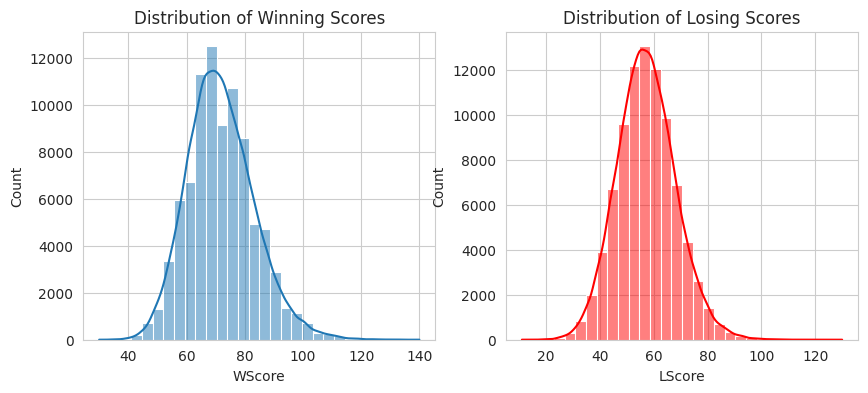

In [379]:
sns.set_style('whitegrid')

# Plot histogram of winning scores
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
sns.histplot(women_detailed['WScore'], bins=30, kde=True)
plt.title('Distribution of Winning Scores')

plt.subplot(1,2,2)
sns.histplot(women_detailed['LScore'], bins=30, kde=True, color='red')
plt.title('Distribution of Losing Scores')
plt.show()

In [380]:
game = women_detailed.iloc[0]

# Winner's possessions
w_poss = game['WFGA'] + 0.44 * game['WFTA'] + game['WTO'] - game['WOR']

# Loser's possessions
l_poss = game['LFGA'] + 0.44 * game['LFTA'] + game['LTO'] - game['LOR']

print(f"Winner possessions: {w_poss:.1f}")
print(f"Loser possessions: {l_poss:.1f}")
print(f"Game pace (avg possessions): {(w_poss + l_poss)/2:.1f}")

Winner possessions: 70.4
Loser possessions: 70.4
Game pace (avg possessions): 70.4


In [381]:
w_oe = game['WScore'] / w_poss * 100  # points per 100 possessions
l_oe = game['LScore'] / l_poss * 100

print(f"Winner offensive efficiency: {w_oe:.1f}")
print(f"Loser offensive efficiency: {l_oe:.1f}")

Winner offensive efficiency: 89.5
Loser offensive efficiency: 69.6


In [382]:
# Calculate possessions for winner and loser for ALL games
women_detailed['WPoss'] = women_detailed['WFGA'] + 0.44 * women_detailed['WFTA'] + women_detailed['WTO'] - women_detailed['WOR']
women_detailed['LPoss'] = women_detailed['LFGA'] + 0.44 * women_detailed['LFTA'] + women_detailed['LTO'] - women_detailed['LOR']

# Calculate offensive efficiency (points per 100 possessions)
women_detailed['WOE'] = women_detailed['WScore'] / women_detailed['WPoss'] * 100
women_detailed['LOE'] = women_detailed['LScore'] / women_detailed['LPoss'] * 100

# Check the new columns
women_detailed[['WPoss', 'LPoss', 'WOE', 'LOE']].head()

,WPoss,LPoss,WOE,LOE
0,70.36,70.40,89.539511,69.602273
1,78.32,80.88,93.207354,84.075173
2,66.28,66.12,107.121304,89.231700
3,76.96,74.00,81.860707,78.378378
4,75.84,76.24,97.573840,91.815320


In [383]:
# Winner shooting
women_detailed['WFGpct'] = women_detailed['WFGM'] / women_detailed['WFGA'].replace(0, np.nan)
women_detailed['W3Ppct'] = women_detailed['WFGM3'] / women_detailed['WFGA3'].replace(0, np.nan)
women_detailed['WFTPct'] = women_detailed['WFTM'] / women_detailed['WFTA'].replace(0, np.nan)
women_detailed['WeFGpct'] = (women_detailed['WFGM'] + 0.5*women_detailed['WFGM3']) / women_detailed['WFGA'].replace(0, np.nan)

# Loser shooting
women_detailed['LFGpct'] = women_detailed['LFGM'] / women_detailed['LFGA'].replace(0, np.nan)
women_detailed['L3Ppct'] = women_detailed['LFGM3'] / women_detailed['LFGA3'].replace(0, np.nan)
women_detailed['LFTPct'] = women_detailed['LFTM'] / women_detailed['LFTA'].replace(0, np.nan)
women_detailed['LeFGpct'] = (women_detailed['LFGM'] + 0.5*women_detailed['LFGM3']) / women_detailed['LFGA'].replace(0, np.nan)
women_detailed.head()

,Season,DayNum,WTeamID,WScore,LTeamID,LScore,WLoc,NumOT,WFGM,WFGA,...,WOE,LOE,WFGpct,W3Ppct,WFTPct,WeFGpct,LFGpct,L3Ppct,LFTPct,LeFGpct
0,2010,11,3103,63,3237,49,H,0,23,54,...,89.539511,69.602273,0.425926,0.555556,0.631579,0.472222,0.370370,0.230769,0.600000,0.398148
1,2010,11,3104,73,3399,68,N,0,26,62,...,93.207354,84.075173,0.419355,0.416667,0.571429,0.459677,0.396825,0.190476,0.518519,0.428571
2,2010,11,3110,71,3224,59,A,0,29,62,...,107.121304,89.231700,0.467742,0.400000,0.583333,0.516129,0.327586,0.142857,0.826087,0.344828
3,2010,11,3111,63,3267,58,A,0,27,52,...,81.860707,78.378378,0.519231,0.363636,0.555556,0.557692,0.243243,0.230769,0.640000,0.283784
4,2010,11,3119,74,3447,70,H,1,30,74,...,97.573840,91.815320,0.405405,0.350000,0.636364,0.452703,0.337838,0.529412,0.523810,0.398649


In [386]:
# Winners
winners = women_detailed[[
    'Season', 'DayNum', 'WTeamID', 'WScore', 'LTeamID', 'LScore',
    'WPoss', 'LPoss', 'WOE', 'LOE', 'WLoc',
    'WFGpct', 'W3Ppct', 'WFTPct', 'WeFGpct',
    'LFGpct', 'L3Ppct', 'LFTPct', 'LeFGpct'
]].copy()
winners.columns = [
    'Season', 'DayNum', 'TeamID', 'TeamScore', 'OppID', 'OppScore',
    'TeamPoss', 'OppPoss', 'TeamOE', 'OppOE', 'Loc',
    'TeamFGpct', 'Team3Ppct', 'TeamFTpct', 'TeameFGpct',
    'OppFGpct', 'Opp3Ppct', 'OppFTpct', 'OppeFGpct'
]
winners['Loc'] = winners['Loc'].map({'H':1, 'A':-1, 'N':0})

# Losers
losers = women_detailed[[
    'Season', 'DayNum', 'LTeamID', 'LScore', 'WTeamID', 'WScore',
    'LPoss', 'WPoss', 'LOE', 'WOE',
    'LFGpct', 'L3Ppct', 'LFTPct', 'LeFGpct',
    'WFGpct', 'W3Ppct', 'WFTPct', 'WeFGpct'
]].copy()
losers.columns = [
    'Season', 'DayNum', 'TeamID', 'TeamScore', 'OppID', 'OppScore',
    'TeamPoss', 'OppPoss', 'TeamOE', 'OppOE',
    'TeamFGpct', 'Team3Ppct', 'TeamFTpct', 'TeameFGpct',
    'OppFGpct', 'Opp3Ppct', 'OppFTpct', 'OppeFGpct'
]
losers['Loc'] = women_detailed['WLoc'].map({'H':-1, 'A':1, 'N':0})

# Combine
women_team_games = pd.concat([winners, losers], ignore_index=True)
women_team_games = women_team_games.sort_values(['Season', 'DayNum', 'TeamID'])

women_team_games.head(10)

,Season,DayNum,TeamID,TeamScore,OppID,OppScore,TeamPoss,OppPoss,TeamOE,OppOE,Loc,TeamFGpct,Team3Ppct,TeamFTpct,TeameFGpct,OppFGpct,Opp3Ppct,OppFTpct,OppeFGpct
87270,2010,11,3102,46,3394,65,68.80,68.92,66.860465,94.312246,-1,0.319149,0.294118,0.550000,0.372340,0.390625,0.111111,0.722222,0.406250
0,2010,11,3103,63,3237,49,70.36,70.40,89.539511,69.602273,1,0.425926,0.555556,0.631579,0.472222,0.370370,0.230769,0.600000,0.398148
1,2010,11,3104,73,3399,68,78.32,80.88,93.207354,84.075173,0,0.419355,0.416667,0.571429,0.459677,0.396825,0.190476,0.518519,0.428571
87238,2010,11,3105,61,3293,72,76.24,75.84,80.010493,94.936709,1,0.385965,0.250000,0.666667,0.412281,0.447761,0.190476,0.727273,0.477612
87217,2010,11,3107,56,3200,76,73.96,73.56,75.716604,103.317020,-1,0.385965,0.294118,0.777778,0.429825,0.547170,0.200000,0.708333,0.556604
87274,2010,11,3108,62,3412,76,72.76,72.44,85.211655,104.914412,-1,0.306452,0.333333,0.655172,0.346774,0.465517,0.416667,0.653846,0.508621
2,2010,11,3110,71,3224,59,66.28,66.12,107.121304,89.231700,-1,0.467742,0.400000,0.583333,0.516129,0.327586,0.142857,0.826087,0.344828
3,2010,11,3111,63,3267,58,76.96,74.00,81.860707,78.378378,-1,0.519231,0.363636,0.555556,0.557692,0.243243,0.230769,0.640000,0.283784
87251,2010,11,3114,58,3329,67,69.16,68.32,83.863505,98.067916,-1,0.400000,0.250000,0.500000,0.425000,0.362069,0.214286,0.785714,0.387931
87235,2010,11,3115,48,3280,106,87.20,87.28,55.045872,121.448213,-1,0.254237,0.157895,0.500000,0.279661,0.447059,0.321429,0.567568,0.500000


In [389]:
# Group by Season and TeamID, calculate mean stats
wteam_season_stats = women_team_games.groupby(['Season', 'TeamID']).agg({
    'TeamOE': 'mean', 'OppOE': 'mean',
    'TeamPoss': 'mean', 'TeamScore': 'mean', 'OppScore': 'mean',
    'TeamFGpct': 'mean', 'Team3Ppct': 'mean', 'TeamFTpct': 'mean', 'TeameFGpct': 'mean',
    'OppFGpct': 'mean', 'Opp3Ppct': 'mean', 'OppFTpct': 'mean', 'OppeFGpct': 'mean'         
}).reset_index()

# Rename columns to include all stats
wteam_season_stats.columns = [
    'Season', 'TeamID', 
    'OffEff', 'DefEff', 'Pace', 'PointsScored', 'PointsAllowed',
    'FGpct', '3Ppct', 'FTpct', 'eFGpct',
    'OppFGpct', 'Opp3Ppct', 'OppFTpct', 'Opp_eFGpct'
]

# Verify all columns are there
print(wteam_season_stats.shape)
print(wteam_season_stats.columns.tolist())

(5965, 15)
['Season', 'TeamID', 'OffEff', 'DefEff', 'Pace', 'PointsScored', 'PointsAllowed', 'FGpct', '3Ppct', 'FTpct', 'eFGpct', 'OppFGpct', 'Opp3Ppct', 'OppFTpct', 'Opp_eFGpct']


In [390]:
# create a lookup of team-season stats
wteam_stats_lookup = wteam_season_stats.set_index(['Season', 'TeamID'])

# Now for each game in team_games, get opponent's OffEff and DefEff
women_team_games['OppOffEff'] = women_team_games.apply(
    lambda row: wteam_stats_lookup.loc[(row['Season'], row['OppID']), 'OffEff'], axis=1
)
women_team_games['OppDefEff'] = women_team_games.apply(
    lambda row: wteam_stats_lookup.loc[(row['Season'], row['OppID']), 'DefEff'], axis=1
)

# Then group by team-season to get average opponent stats
sos_stats = women_team_games.groupby(['Season', 'TeamID']).agg({
    'OppOffEff': 'mean',   # average offensive efficiency of opponents (how good they were on offense)
    'OppDefEff': 'mean'    # average defensive efficiency of opponents (how good they were on defense)
}).reset_index()

# Merge with existing team_season_stats
wteam_season_stats = wteam_season_stats.merge(sos_stats, on=['Season', 'TeamID'])

# Now we have SOS info: a team faced opponents that on average had OffEff X and DefEff Y.
wteam_season_stats.head()

,Season,TeamID,OffEff,DefEff,Pace,PointsScored,PointsAllowed,FGpct,3Ppct,FTpct,eFGpct,OppFGpct,Opp3Ppct,OppFTpct,Opp_eFGpct,OppOffEff,OppDefEff
0,2010,3102,80.796772,111.741358,64.207143,51.821429,71.785714,0.364342,0.281453,0.684589,0.407876,0.483364,0.369639,0.660875,0.552735,92.867876,89.669342
1,2010,3103,91.820972,87.538342,67.957333,62.233333,59.633333,0.405346,0.321613,0.704329,0.441526,0.384250,0.327126,0.690810,0.428748,91.083283,91.746648
2,2010,3104,86.332655,90.469254,74.182069,64.137931,67.000000,0.400770,0.312620,0.621109,0.436584,0.398627,0.319494,0.630059,0.440119,91.898804,89.439957
3,2010,3105,83.371386,88.504787,72.928889,60.777778,64.740741,0.407713,0.308731,0.694134,0.437404,0.398291,0.301999,0.653417,0.431373,84.128372,89.387268
4,2010,3106,80.471360,83.654713,68.663448,55.137931,57.413793,0.352129,0.290696,0.642189,0.377771,0.353987,0.291963,0.678349,0.389762,82.475143,87.431837


In [391]:
# # Ensure consistent integer types for merging
# women_team_games['Season'] = women_team_games['Season'].astype(int)
# women_team_games['OppID'] = women_team_games['OppID'].astype(int)

# # Prepare a lookup DataFrame with opponent stats (only the columns we need)
# opp_stats = wteam_season_stats[['Season', 'TeamID', 'OffEff', 'DefEff']].copy()
# opp_stats.columns = ['Season', 'OppID', 'OppOffEff', 'OppDefEff']   # rename for merge
# opp_stats['Season'] = opp_stats['Season'].astype(int)
# opp_stats['OppID'] = opp_stats['OppID'].astype(int)

# # Merge opponent stats directly into team_games (left join keeps all games)
# women_team_games = women_team_games.merge(opp_stats, on=['Season', 'OppID'], how='left')

# # Compute SOS (average opponent stats) per team‑season
# sos_stats = women_team_games.groupby(['Season', 'TeamID']).agg({
#     'OppOffEff': 'mean',
#     'OppDefEff': 'mean'
# }).reset_index()

# # Merge the SOS back into your main team_season_stats
# wteam_season_stats = wteam_season_stats.merge(sos_stats, on=['Season', 'TeamID'], how='left')

# # Verify
# wteam_season_stats.head()

In [397]:
# Drop the duplicate '_y' columns and rename '_x' to the original names
women_stats = wteam_season_stats[[col for col in wteam_season_stats.columns if not col.endswith('_y')]]
women_stats.columns = [col.replace('_x', '') if col.endswith('_x') else col for col in women_stats.columns]

# Now men_stats should have clean columns: Season, TeamID, OffEff, DefEff, Pace, PointsScored, PointsAllowed, OppOffEff, OppDefEff
women_stats.head()

,Season,TeamID,OffEff,DefEff,Pace,PointsScored,PointsAllowed,FGpct,3Ppct,FTpct,eFGpct,OppFGpct,Opp3Ppct,OppFTpct,Opp_eFGpct,OppOffEff,OppDefEff
0,2010,3102,80.796772,111.741358,64.207143,51.821429,71.785714,0.364342,0.281453,0.684589,0.407876,0.483364,0.369639,0.660875,0.552735,92.867876,89.669342
1,2010,3103,91.820972,87.538342,67.957333,62.233333,59.633333,0.405346,0.321613,0.704329,0.441526,0.384250,0.327126,0.690810,0.428748,91.083283,91.746648
2,2010,3104,86.332655,90.469254,74.182069,64.137931,67.000000,0.400770,0.312620,0.621109,0.436584,0.398627,0.319494,0.630059,0.440119,91.898804,89.439957
3,2010,3105,83.371386,88.504787,72.928889,60.777778,64.740741,0.407713,0.308731,0.694134,0.437404,0.398291,0.301999,0.653417,0.431373,84.128372,89.387268
4,2010,3106,80.471360,83.654713,68.663448,55.137931,57.413793,0.352129,0.290696,0.642189,0.377771,0.353987,0.291963,0.678349,0.389762,82.475143,87.431837


In [398]:
print("women_stats shape:", women_stats.shape)
print(women_stats.head())

women_stats shape: (5965, 17)
   Season  TeamID     OffEff      DefEff       Pace  PointsScored  \
0    2010    3102  80.796772  111.741358  64.207143     51.821429   
1    2010    3103  91.820972   87.538342  67.957333     62.233333   
2    2010    3104  86.332655   90.469254  74.182069     64.137931   
3    2010    3105  83.371386   88.504787  72.928889     60.777778   
4    2010    3106  80.471360   83.654713  68.663448     55.137931   

   PointsAllowed     FGpct     3Ppct     FTpct    eFGpct  OppFGpct  Opp3Ppct  \
0      71.785714  0.364342  0.281453  0.684589  0.407876  0.483364  0.369639   
1      59.633333  0.405346  0.321613  0.704329  0.441526  0.384250  0.327126   
2      67.000000  0.400770  0.312620  0.621109  0.436584  0.398627  0.319494   
3      64.740741  0.407713  0.308731  0.694134  0.437404  0.398291  0.301999   
4      57.413793  0.352129  0.290696  0.642189  0.377771  0.353987  0.291963   

   OppFTpct  Opp_eFGpct  OppOffEff  OppDefEff  
0  0.660875    0.552735  9

In [399]:
print("women_teams shape:", women_teams.shape)
print(women_teams.head())

women_teams shape: (379, 2)
   TeamID     TeamName
0    3101  Abilene Chr
1    3102    Air Force
2    3103        Akron
3    3104      Alabama
4    3105  Alabama A&M


In [400]:
print("women_stats TeamID dtype:", women_stats['TeamID'].dtype)
print("women_teams TeamID dtype:", women_teams['TeamID'].dtype)

women_stats TeamID dtype: int64
women_teams TeamID dtype: int64


In [401]:
sample_id = women_stats['TeamID'].iloc[0]
print("Sample TeamID:", sample_id)
print(women_teams[women_teams['TeamID'] == sample_id])

Sample TeamID: 3102
   TeamID   TeamName
1    3102  Air Force


In [402]:
women_teams = pd.read_csv('/kaggle/input/competitions/march-machine-learning-mania-2026/WTeams.csv')
women_stats_with_names = women_stats.merge(women_teams, on='TeamID')
# Look at extreme examples
print("Highest offensive efficiency:")
print(women_stats_with_names.nlargest(10, 'OffEff')[['Season', 'TeamName', 'OffEff', 'DefEff', 'OppOffEff', 'OppDefEff']])
print("\nLowest defensive efficiency (best defense):")
print(women_stats_with_names.nsmallest(10, 'DefEff')[['Season', 'TeamName', 'OffEff', 'DefEff', 'OppOffEff', 'OppDefEff']])

Highest offensive efficiency:
      Season        TeamName      OffEff     DefEff   OppOffEff  OppDefEff
1777    2015     Connecticut  127.493932  67.422193   92.784702  90.250562
3689    2020          Oregon  124.877013  85.153547   96.796865  90.589307
2126    2016     Connecticut  123.930384  67.089581   94.305105  90.823018
2475    2017     Connecticut  123.137601  76.517291   97.509245  90.080872
3338    2019          Oregon  122.521852  92.954403  100.772029  93.677150
2824    2018     Connecticut  122.208037  72.068163   97.871343  91.866870
3289    2019  Mississippi St  121.086048  82.207756   96.356055  92.120411
3971    2021        Maryland  120.222001  92.644331   97.566313  95.935756
5904    2026            UCLA  120.035490  80.655823   99.784283  90.519715
2579    2017        Maryland  119.871168  85.752593   95.362673  93.820515

Lowest defensive efficiency (best defense):
      Season     TeamName      OffEff     DefEff  OppOffEff  OppDefEff
55      2010  Connecticut  11

In [413]:
def compute_team_stats(season, detailed_df, teams_df):
    """
    Given a season (e.g., 2026) and the detailed results DataFrame for that season,
    returns a DataFrame with team-season stats including SOS.
    """
    # Filter to the season
    df = detailed_df[detailed_df['Season'] == season].copy()
    
    # Compute possessions and efficiency for each game
    df['WPoss'] = df['WFGA'] + 0.44*df['WFTA'] + df['WTO'] - df['WOR']
    df['LPoss'] = df['LFGA'] + 0.44*df['LFTA'] + df['LTO'] - df['LOR']
    df['WOE'] = df['WScore'] / df['WPoss'] * 100
    df['LOE'] = df['LScore'] / df['LPoss'] * 100
    
    # Create team-game view
    winners = df[['Season', 'DayNum', 'WTeamID', 'WScore', 'LTeamID', 'LScore', 'WPoss', 'LPoss', 'WOE', 'LOE', 'WLoc']].copy()
    winners.columns = ['Season', 'DayNum', 'TeamID', 'TeamScore', 'OppID', 'OppScore', 'TeamPoss', 'OppPoss', 'TeamOE', 'OppOE', 'Loc']
    winners['Loc'] = winners['Loc'].map({'H':1, 'A':-1, 'N':0})
    
    losers = df[['Season', 'DayNum', 'LTeamID', 'LScore', 'WTeamID', 'WScore', 'LPoss', 'WPoss', 'LOE', 'WOE']].copy()
    losers.columns = ['Season', 'DayNum', 'TeamID', 'TeamScore', 'OppID', 'OppScore', 'TeamPoss', 'OppPoss', 'TeamOE', 'OppOE']
    losers['Loc'] = df['WLoc'].map({'H':-1, 'A':1, 'N':0})
    
    wteam_games = pd.concat([winners, losers], ignore_index=True)
    wteam_games = wteam_games.sort_values(['Season', 'DayNum', 'TeamID'])
    
    # Aggregate to team-season (raw stats)
    raw_stats = wteam_games.groupby(['Season', 'TeamID']).agg({
        'TeamOE': 'mean',
        'OppOE': 'mean',
        'TeamPoss': 'mean',
        'TeamScore': 'mean',
        'OppScore': 'mean'
    }).rename(columns={
        'TeamOE': 'OffEff',
        'OppOE': 'DefEff',
        'TeamPoss': 'Pace',
        'TeamScore': 'PointsScored',
        'OppScore': 'PointsAllowed'
    }).reset_index()
    
    # Need to get opponent stats for SOS – we need a lookup of raw_stats by (Season, TeamID)
    lookup = raw_stats.set_index(['Season', 'TeamID'])
    
    # Merge opponent stats into team_games
    wteam_games['OppOffEff'] = wteam_games.apply(
        lambda row: lookup.loc[(row['Season'], row['OppID']), 'OffEff'] 
        if (row['Season'], row['OppID']) in lookup.index else np.nan, axis=1
    )
    wteam_games['OppDefEff'] = wteam_games.apply(
        lambda row: lookup.loc[(row['Season'], row['OppID']), 'DefEff']
        if (row['Season'], row['OppID']) in lookup.index else np.nan, axis=1
    )
    
    # Average opponent stats per team
    sos = wteam_games.groupby(['Season', 'TeamID']).agg({
        'OppOffEff': 'mean',
        'OppDefEff': 'mean'
    }).rename(columns={
        'OppOffEff': 'OppOffEff',
        'OppDefEff': 'OppDefEff'
    }).reset_index()
    
    # Merge SOS with raw_stats
    final_stats = raw_stats.merge(sos, on=['Season', 'TeamID'])
    
    # Optionally merge team names
    final_stats = final_stats.merge(teams_df, on='TeamID', how='left')
    
    return final_stats

In [40]:
# Call the function
# women_2026_stats = compute_team_stats(2026, women_detailed_all, women_teams)

In [414]:
women_tourney = pd.read_csv('/kaggle/input/competitions/march-machine-learning-mania-2026/WNCAATourneyDetailedResults.csv')

print(women_tourney.shape)
print(women_tourney.columns)

(961, 34)
Index(['Season', 'DayNum', 'WTeamID', 'WScore', 'LTeamID', 'LScore', 'WLoc',
       'NumOT', 'WFGM', 'WFGA', 'WFGM3', 'WFGA3', 'WFTM', 'WFTA', 'WOR', 'WDR',
       'WAst', 'WTO', 'WStl', 'WBlk', 'WPF', 'LFGM', 'LFGA', 'LFGM3', 'LFGA3',
       'LFTM', 'LFTA', 'LOR', 'LDR', 'LAst', 'LTO', 'LStl', 'LBlk', 'LPF'],
      dtype='object')


In [422]:
# Create a lookup: (Season, TeamID) -> stats
women_stats_lookup = women_stats.set_index(['Season', 'TeamID'])

In [429]:
def prepare_training_data_v2(tourney_df, stats_df):
    rows = []
    for idx, game in tourney_df.iterrows():
        season = game['Season']
        wteam = game['WTeamID']
        lteam = game['LTeamID']
        
        if wteam < lteam:
            teamA, teamB, target = wteam, lteam, 1
        else:
            teamA, teamB, target = lteam, wteam, 0
        
        statsA = stats_df[(stats_df['Season'] == season) & (stats_df['TeamID'] == teamA)]
        statsB = stats_df[(stats_df['Season'] == season) & (stats_df['TeamID'] == teamB)]
        if len(statsA) == 0 or len(statsB) == 0:
            continue
        statsA = statsA.iloc[0]
        statsB = statsB.iloc[0]
        
        row = {
            'Season': season,
            'TeamA': teamA,
            'TeamB': teamB,
            'OffEff_diff': statsA['OffEff'] - statsB['OffEff'],
            'DefEff_diff': statsA['DefEff'] - statsB['DefEff'],
            'Pace_diff': statsA['Pace'] - statsB['Pace'],
            'PointsScored_diff': statsA['PointsScored'] - statsB['PointsScored'],
            'PointsAllowed_diff': statsA['PointsAllowed'] - statsB['PointsAllowed'],
            'FGpct_diff': statsA['FGpct'] - statsB['FGpct'],
            '3Ppct_diff': statsA['3Ppct'] - statsB['3Ppct'],
            'FTpct_diff': statsA['FTpct'] - statsB['FTpct'],
            'eFGpct_diff': statsA['eFGpct'] - statsB['eFGpct'],
            'OppFGpct_diff': statsA['OppFGpct'] - statsB['OppFGpct'],
            'Opp3Ppct_diff': statsA['Opp3Ppct'] - statsB['Opp3Ppct'],
            'OppFTpct_diff': statsA['OppFTpct'] - statsB['OppFTpct'],
            'Opp_eFGpct_diff': statsA['Opp_eFGpct'] - statsB['Opp_eFGpct'],
            'OppOffEff_diff': statsA.get('OppOffEff', 0) - statsB.get('OppOffEff', 0),  # if you have these
            'OppDefEff_diff': statsA.get('OppDefEff', 0) - statsB.get('OppDefEff', 0),
            'target': target
        }
        rows.append(row)
    return pd.DataFrame(rows)

women_train = prepare_training_data_v2(women_tourney, women_stats)  # use the final men_stats with all columns
print(women_train.head())

   Season  TeamA  TeamB  OffEff_diff  DefEff_diff  Pace_diff  \
0    2010   3124   3201    -2.177115    -4.194710   0.231250   
1    2010   3173   3395    -0.807917    -0.426381  -0.614462   
2    2010   3181   3214     6.525141    -2.882899   3.808917   
3    2010   3199   3256     2.440980    -2.339454  -1.657247   
4    2010   3207   3265    -3.627338    -2.257922   2.594667   

   PointsScored_diff  PointsAllowed_diff  FGpct_diff  3Ppct_diff  FTpct_diff  \
0          -1.360795           -3.732008    0.041469   -0.046376    0.023243   
1          -1.530769           -0.800000    0.006175   -0.055251   -0.049986   
2           8.760417           -0.070833    0.049980    0.015307   -0.054275   
3           0.208602           -4.222581    0.011937    0.073379    0.028920   
4          -0.148485            0.457576   -0.023361   -0.028531   -0.083745   

   eFGpct_diff  OppFGpct_diff  Opp3Ppct_diff  OppFTpct_diff  Opp_eFGpct_diff  \
0    -0.008096      -0.067650      -0.022591       0.0

In [442]:
feature_cols = [
    'OffEff_diff', 'DefEff_diff', 'Pace_diff', 
    'PointsScored_diff', 'PointsAllowed_diff',
    'FGpct_diff', '3Ppct_diff', 'FTpct_diff', 'eFGpct_diff',
    'OppFGpct_diff', 'Opp3Ppct_diff', 'OppFTpct_diff', 'Opp_eFGpct_diff',
    'OppOffEff_diff', 'OppDefEff_diff'
]

X = women_train[feature_cols]
y = women_train['target']

# Chronological split: train on older seasons, validate on recent
# Let's use seasons up to 2019 for training, 2021-2024 for validation (since 2020 tournament was canceled?)
# Actually 2020 tournament was canceled, so we might skip 2020.
train_mask = women_train['Season'] <= 2019
val_mask = women_train['Season'] >= 2021  # assuming 2021-2024 are available

X_train, X_val = X[train_mask], X[val_mask]
y_train, y_val = y[train_mask], y[val_mask]

# Train model
women_model = LogisticRegression(C=1.0, penalty='l2', solver='lbfgs')
women_model.fit(X_train, y_train)

# Predict probabilities
y_pred_proba = women_model.predict_proba(X_val)[:, 1]

# Evaluate with Brier score (mean squared error of probabilities)
brier = brier_score_loss(y_val, y_pred_proba)
print(f"Validation Brier score: {brier:.4f}")

Validation Brier score: 0.1508


In [434]:
xgb_model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)
xgb_model.fit(X_train, y_train)

# Predict probabilities
y_pred_xgb = xgb_model.predict_proba(X_val)[:, 1]
brier_xgb = brier_score_loss(y_val, y_pred_xgb)
print(f"XGBoost Brier: {brier_xgb:.4f}")

XGBoost Brier: 0.1733


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [10:17:42] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [435]:
print(women_train['target'].mean())

0.5046826222684704


# Merging Both MEN's and WOMEN's Combined Submission

In [436]:
# Men
men_teams_2026 = men_2026['TeamID'].unique()
men_pairs = list(combinations(sorted(men_teams_2026), 2))
print(f"Number of men's matchups: {len(men_pairs)}")

# Women
women_teams_2026 = women_stats[women_stats['Season'] == 2026]['TeamID'].unique()
women_pairs = list(combinations(sorted(women_teams_2026), 2))
print(f"Number of women's matchups: {len(women_pairs)}")

Number of men's matchups: 66430
Number of women's matchups: 65703


In [445]:
def generate_submission(model, season, stats_df, feature_cols):
    """
    Generate predictions for every possible matchup in a given season.
    
    Parameters:
    - model: trained sklearn model (with predict_proba)
    - season: int, e.g., 2026
    - stats_df: DataFrame with team-season stats (must contain all base columns needed)
    - feature_cols: list of feature names used during training (e.g., ['OffEff_diff', 'DefEff_diff', ...])
    """
    # Get all teams for that season
    teams = stats_df[stats_df['Season'] == season]['TeamID'].unique()
    teams = sorted(teams)
    pairs = list(combinations(teams, 2))
    
    rows = []
    for teamA, teamB in pairs:
        # Extract stats for both teams
        statsA = stats_df[(stats_df['Season'] == season) & (stats_df['TeamID'] == teamA)].iloc[0]
        statsB = stats_df[(stats_df['Season'] == season) & (stats_df['TeamID'] == teamB)].iloc[0]
        
        # Build a dictionary of features with proper names
        feat_dict = {}
        for col in feature_cols:
            # All our features are differences, named like 'OffEff_diff'
            if col.endswith('_diff'):
                base_name = col[:-5]  # remove '_diff' to get base column (e.g., 'OffEff')
                feat_dict[col] = statsA[base_name] - statsB[base_name]
            else:
                # If you ever add non-diff features, handle them here
                # For now, assume all are diffs
                pass
        
        # Convert to DataFrame with one row (to keep feature names)
        X_pred = pd.DataFrame([feat_dict])
        
        # Predict probability that teamA (lower ID) wins
        prob = model.predict_proba(X_pred)[0, 1]
        
        game_id = f"{season}_{teamA}_{teamB}"
        rows.append({'ID': game_id, 'Pred': prob})
    
    return pd.DataFrame(rows)

# For men
men_sub = generate_submission(model, 2026, men_stats, feature_cols)

# For women (assuming you trained a separate model)
women_sub = generate_submission(women_model, 2026, women_stats, feature_cols)

# Combine and save
submission = pd.concat([men_sub, women_sub], ignore_index=True)
submission.to_csv('submission.csv', index=False)